https://www.kaggle.com/datasets/syedmuhammadbilal12/mount-everest-accident-dataset-2020-2025

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('Mount Everest Accident Dataset 2020-2025.csv')

In [3]:
df.head()

,Date,Name,Nationality,Age,Gender,Cause_of_Death,Altitude_meters,Location,Route,Season,Weather_Conditions,Experience_Level,Expedition_Company
0,2021-07-12,Dmitri White,India,63,Male,Exhaustion,8000,Summit (8848m),Southwest Face,Summer (Jun-Aug),Snowstorm,Expert (6+ previous 8000m peaks),Peak Freaks
1,2023-06-28,Sandra Verma,Sweden,43,Male,Exhaustion,8400,Summit (8848m),North Face,Summer (Jun-Aug),Clear,Experienced (3-5 previous 8000m peaks),Alpine Ascents
2,2023-09-23,Andrew Ito,Switzerland,31,Female,Altitude Sickness (AMS/HAPE/HACE),8400,Balcony (8400m),Southwest Face,Summer (Jun-Aug),Whiteout,Experienced (3-5 previous 8000m peaks),Seven Summits Treks
3,2025-12-29,Donna Kato,Czech Republic,35,Male,Disorientation/Lost,6065,Camp 2 (6400m),South Col Route (Nepal),Winter (Dec-Feb),Extreme cold,Intermediate (1-2 previous 8000m peaks),Mountain Madness
4,2025-11-09,James Martin,Denmark,32,Male,Altitude Sickness (AMS/HAPE/HACE),8000,Lhotse Face,East Face,Autumn (Oct-Nov),Snowstorm,Intermediate (1-2 previous 8000m peaks),Climbing the Seven Summits


In [4]:
df.tail()

,Date,Name,Nationality,Age,Gender,Cause_of_Death,Altitude_meters,Location,Route,Season,Weather_Conditions,Experience_Level,Expedition_Company
495,2025-11-10,Michelle Brown,China,30,Female,Icefall,6400,Camp 2 (6400m),South Col Route (Nepal),Autumn (Oct-Nov),Snowstorm,Novice (First 8000m peak),Peak Freaks
496,2021-04-15,Alexei Watanabe,Spain,28,Female,Rockfall,8000,Lhotse Face,East Face,Spring (Apr-May),Whiteout,Professional Guide,Elite Exped
497,2022-06-11,Thomas Walker,China,28,Male,Altitude Sickness (AMS/HAPE/HACE),8790,Balcony (8400m),West Ridge,Summer (Jun-Aug),Mixed conditions,Experienced (3-5 previous 8000m peaks),Mountain Madness
498,2024-12-24,Sophie Harris,China,31,Female,Altitude Sickness (AMS/HAPE/HACE),8000,Lhotse Face,East Face,Winter (Dec-Feb),Snowstorm,Intermediate (1-2 previous 8000m peaks),Furtenbach Adventures
499,2021-03-07,Mei Popov,Russia,61,Male,Hypothermia,8400,Yellow Band,South Col Route (Nepal),Summer (Jun-Aug),High winds,Intermediate (1-2 previous 8000m peaks),Climbing the Seven Summits


In [5]:
df.shape

(500, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                500 non-null    object
 1   Name                500 non-null    object
 2   Nationality         500 non-null    object
 3   Age                 500 non-null    int64 
 4   Gender              500 non-null    object
 5   Cause_of_Death      500 non-null    object
 6   Altitude_meters     500 non-null    int64 
 7   Location            500 non-null    object
 8   Route               500 non-null    object
 9   Season              500 non-null    object
 10  Weather_Conditions  500 non-null    object
 11  Experience_Level    500 non-null    object
 12  Expedition_Company  500 non-null    object
dtypes: int64(2), object(11)
memory usage: 50.9+ KB


In [7]:
df.columns

Index(['Date', 'Name', 'Nationality', 'Age', 'Gender', 'Cause_of_Death',
       'Altitude_meters', 'Location', 'Route', 'Season', 'Weather_Conditions',
       'Experience_Level', 'Expedition_Company'],
      dtype='object')

In [8]:
df.isnull().sum()

Date                  0
Name                  0
Nationality           0
Age                   0
Gender                0
Cause_of_Death        0
Altitude_meters       0
Location              0
Route                 0
Season                0
Weather_Conditions    0
Experience_Level      0
Expedition_Company    0
dtype: int64

In [9]:
df = df.drop_duplicates()
df = df.dropna(subset=['Route', 'Cause_of_Death'])
df['Route'] = df['Route'].str.strip()

1. Which route has the highest mortality rate?

In [10]:
route_deaths = df['Route'].value_counts()
print(route_deaths)

East Face                        88
Southwest Face                   87
South Col Route (Nepal)          86
North Face                       81
West Ridge                       79
Northeast Ridge Route (Tibet)    79
Name: Route, dtype: int64


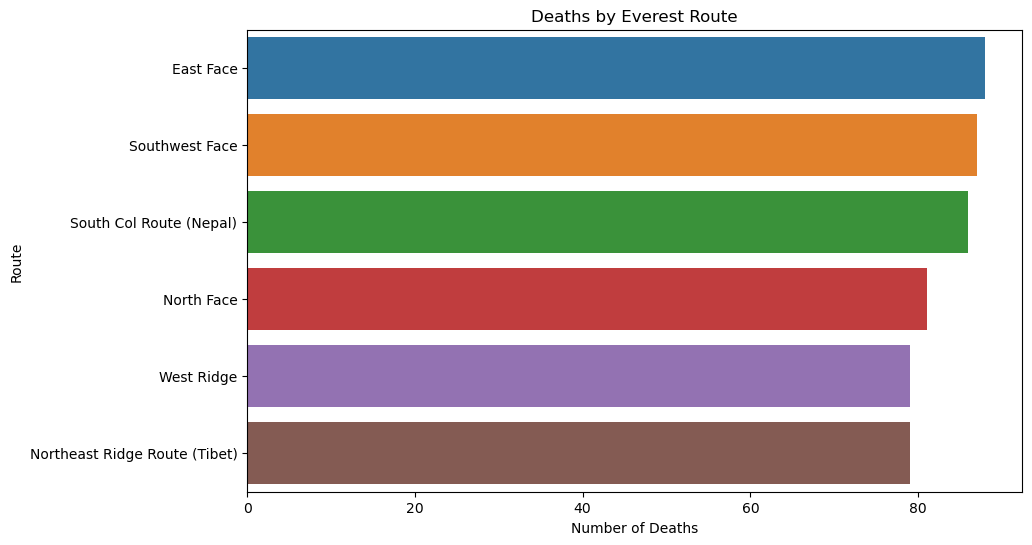

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Route', order=df['Route'].value_counts().index)
plt.title("Deaths by Everest Route")
plt.xlabel("Number of Deaths")
plt.ylabel("Route")
plt.show()

2. At what altitude do most deaths occur?

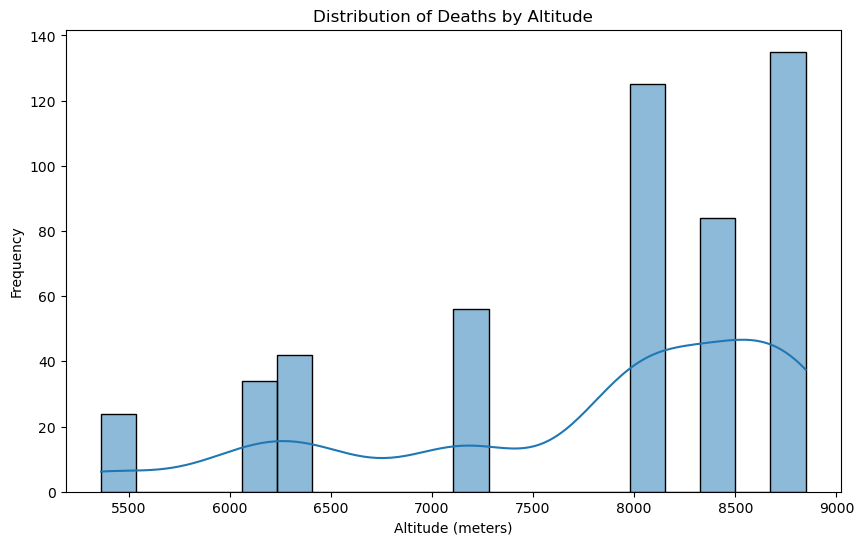

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['Altitude_meters'], bins=20, kde=True)
plt.title("Distribution of Deaths by Altitude")
plt.xlabel("Altitude (meters)")
plt.ylabel("Frequency")
plt.show()

In [13]:
death_zone = df[df['Altitude_meters'] >= 8000]
print("Deaths above 8000m:", len(death_zone))

Deaths above 8000m: 344


3. How do weather and season affect fatalities?

In [14]:
weather_counts = df['Weather_Conditions'].value_counts()
print(weather_counts)

Extreme cold        75
Mixed conditions    66
High winds          63
Cloudy              63
Clear               60
Blizzard            60
Snowstorm           57
Whiteout            56
Name: Weather_Conditions, dtype: int64


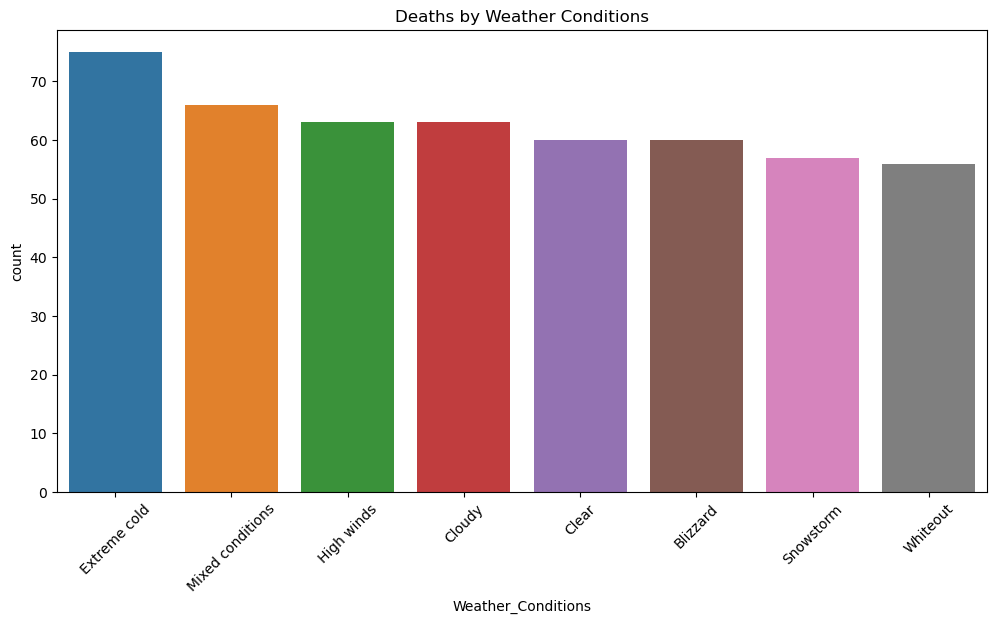

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Weather_Conditions',
              order=df['Weather_Conditions'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Deaths by Weather Conditions")
plt.show()

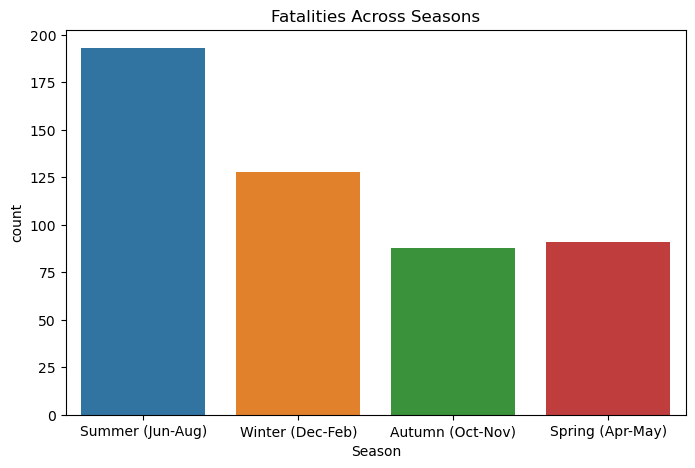

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Season')
plt.title("Fatalities Across Seasons")
plt.show()

4. Does experience level affect survival risk?

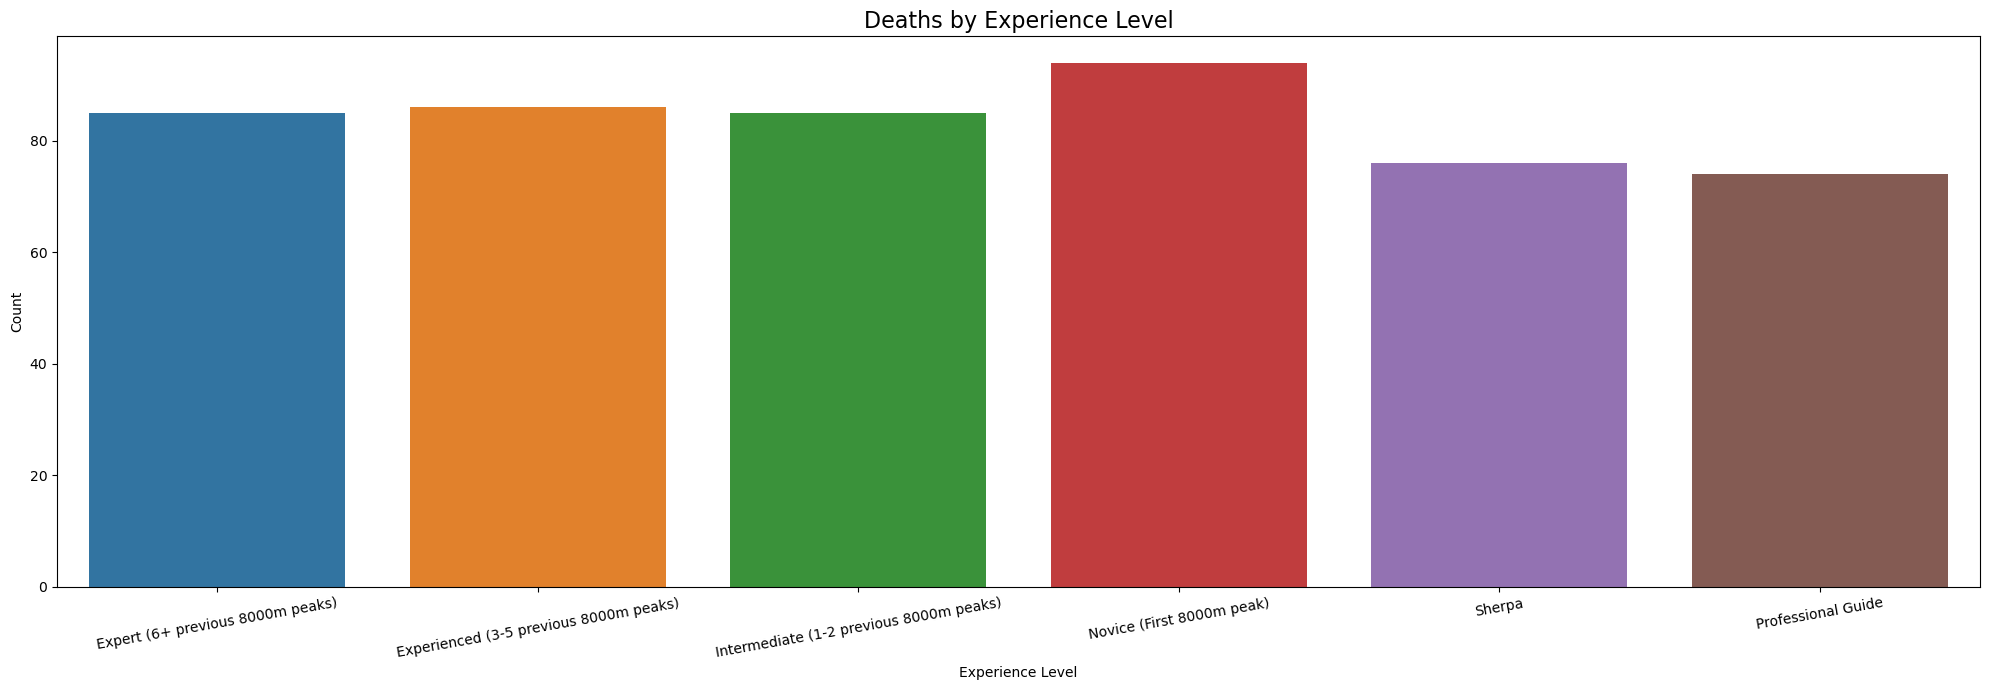

In [22]:
plt.figure(figsize=(20,7))
sns.countplot(data=df, x='Experience_Level')
plt.title("Deaths by Experience Level", fontsize=16)
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

5. Which route offers the safest overall expedition?

In [23]:
route_stats = df.groupby('Route').agg({
    'Altitude_meters':'mean',
    'Name':'count'
}).reset_index()
route_stats.columns = ['Route', 'Avg_Altitude_Deaths', 'Death_Count']
route_stats['Safety_Score'] = (
    route_stats['Death_Count'] * 0.7 +
    route_stats['Avg_Altitude_Deaths']/1000 * 0.3
)
print(route_stats.sort_values('Safety_Score'))

                           Route  Avg_Altitude_Deaths  Death_Count  \
5                     West Ridge          7783.658228           79   
2  Northeast Ridge Route (Tibet)          7808.151899           79   
1                     North Face          7710.061728           81   
3        South Col Route (Nepal)          7840.127907           86   
4                 Southwest Face          7842.954023           87   
0                      East Face          7746.477273           88   

   Safety_Score  
5     57.635097  
2     57.642446  
1     59.013019  
3     62.552038  
4     63.252886  
0     63.923943  


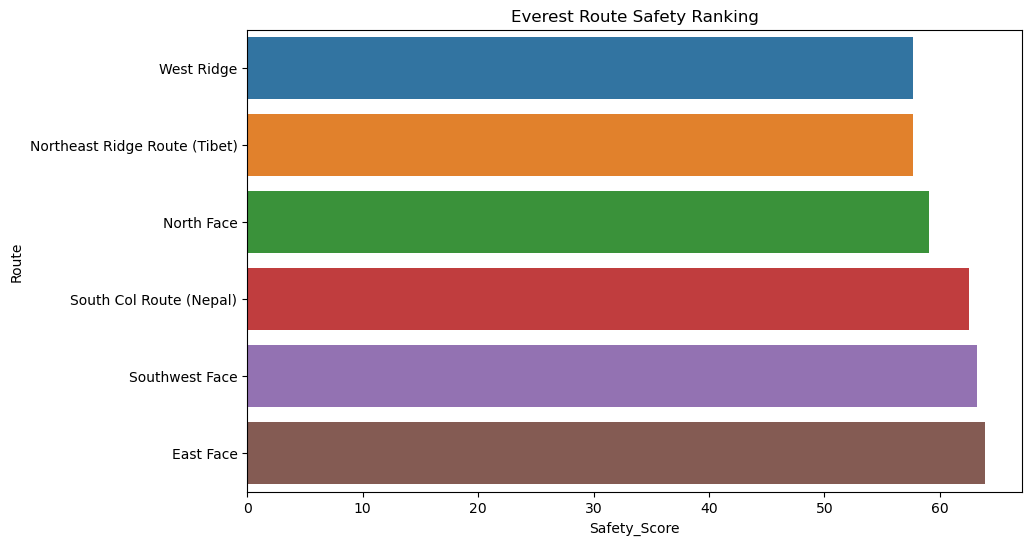

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=route_stats.sort_values('Safety_Score'),
            x='Safety_Score',
            y='Route')
plt.title("Everest Route Safety Ranking")
plt.show()

6. Create a model to identify the optimal route

In [31]:
conditions = [
    (df['Altitude_meters'] < 7000),
    (df['Altitude_meters'] >= 7000) &
    (df['Altitude_meters'] < 8000),
    (df['Altitude_meters'] >= 8000)
]

risk_labels = [
    'Low Risk',
    'Medium Risk',
    'High Risk'
]

df['Risk_Level'] = np.select(
    conditions,
    risk_labels
)

In [32]:
from sklearn.tree import DecisionTreeClassifier

X = df[['Altitude_meters']]

y = df['Risk_Level']

model = DecisionTreeClassifier()

model.fit(X, y)

DecisionTreeClassifier()

In [33]:
model.predict([[8500]])

D:\Python\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['High Risk'], dtype=object)

In [35]:
model.predict([[6000]])

D:\Python\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Low Risk'], dtype=object)

7. Geographical mapping

In [37]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

safe_routes = pd.DataFrame({
    'Route': [
        'South Col Route',
        'Southeast Ridge',
        'Northeast Ridge',
        'North Col Route',
        'West Ridge'
    ],
    
    'Latitude': [
        27.9881,
        27.9800,
        28.0050,
        28.0100,
        27.9700
    ],
    
    'Longitude': [
        86.9250,
        86.9300,
        86.9450,
        86.9500,
        86.9100
    ],
    
    'Safety_Score': [
        92,
        88,
        80,
        76,
        70
    ]
})

everest_map = folium.Map(
    location=[27.9881, 86.9250],
    zoom_start=10,
    tiles='OpenStreetMap'
)


marker_cluster = MarkerCluster().add_to(everest_map)

for idx, row in safe_routes.iterrows():
    
    popup_text = f"""
    <b>Route:</b> {row['Route']}<br>
    <b>Safety Score:</b> {row['Safety_Score']}
    """
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=popup_text,
        tooltip=row['Route'],
        icon=folium.Icon(color='green', icon='info-sign')
    ).add_to(marker_cluster)


everest_map.save("everest_safe_routes_map.html")
print("Map Created Successfully!")

Map Created Successfully!
